# Notebook e reprodutibilidade

As dependências exata do ambiente Julia está em `Manifest.toml`e `Project.toml`. Em _teoria_ o pacote `StableRNG` deve garantir que as figuras sejam reprodutivas.

In [3]:
using CairoMakie
using Distributions
using Random
using Statistics
using StableRNGs
using OffsetArrays
using StatsBase
using BenchmarkTools
rng = StableRNG(123456789)

StableRNGs.LehmerRNG(state=0x0000000000000000000000000eb79a2b)

# Questão 10

### a) 
Uma gaussiana é a uma distribuição de probabilidades "bem comportadas" em termos de momentos, a integral de $x^ne^{x^{-2}/2}$ devido a sua rápida queda, converge para qualquer $n \in \mathbb{R}$. Portanto, é esperado que a média amostral se aproxime da média teórica conforme $n \to \infty$.

Já para a distribuição de Cauchy que não tem esperança bem definida, é esperado que a média não convirja e somente oscile aleatóriamente  

### b)

Como esperado, a gaussiana de fato se aproximou de ter $\mu=0$ e $\sigma=1$ enquanto a a distribuição de Cauchy demonstrou o seu caráter patológico. É interessante ver que o desvio padrão oscilou por uma ordem de grandeza a mais do que a média, provavelmente por envolver termos ao quadrado

Gaussiana média final = -0.0007357748550939578
Gaussiana desvio padrão final = 0.9876842296969667


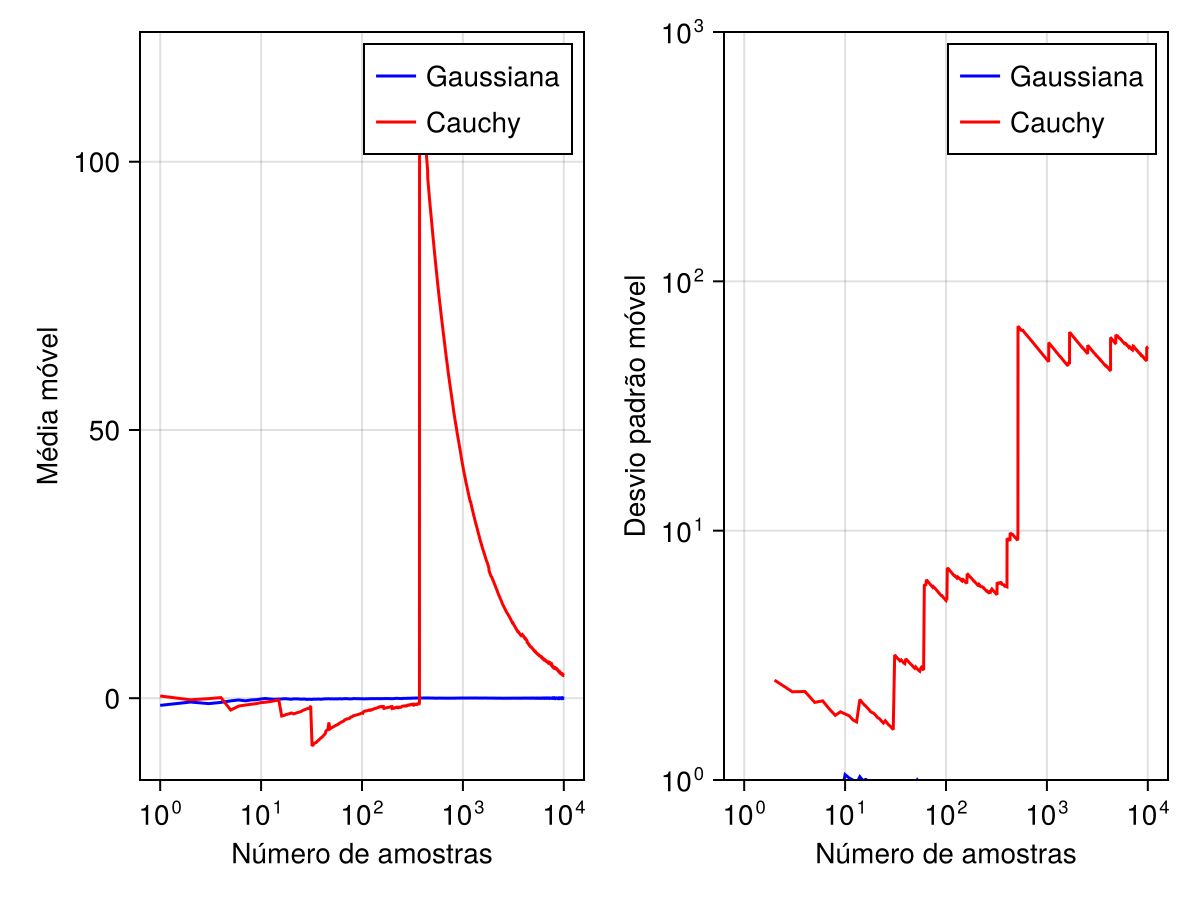

In [4]:
#Para o código ser eficiente, vamos usar dois truques para
# calcularmos a média e o desvio padrão acumulados em O(n)

#μₙ = μₙ₋₁ + (xₙ - μₙ₋₁) / n.
function running_mean(values)
    Iterators.accumulate(enumerate(values); init=0.0) do μ, (n, x)
        μ + (x - μ) / n
    end
end

#Var(X) = E[X²] - E[X]²
function running_std(values)
    means = running_mean(values)
    mean_squares = running_mean(x^2 for x in values)
    Iterators.map(zip(means, mean_squares)) do (μ, μ₂)
        sqrt(μ₂ - μ^2)
    end
end
N=10_000

gauss=Normal(0.0,1.0)
cauchy=Cauchy(0.0,1.0)
fig=Figure()
ax_mean=Axis(fig[1,1],xscale=log10,xlabel="Número de amostras",ylabel="Média móvel")
ax_std=Axis(fig[1,2],xscale=log10,yscale=log10,xlabel="Número de amostras",ylabel="Desvio padrão móvel")
means_gauss=collect(running_mean(rand(rng,gauss,N)))
means_cauchy=collect(running_mean(rand(rng,cauchy,N)))

lines!(ax_mean,1:N,means_gauss,label="Gaussiana",color=:blue)
lines!(ax_mean,1:N,means_cauchy,label="Cauchy",color=:red)

stds_gauss=collect(running_std(rand(rng,gauss,N)))
stds_cauchy=collect(running_std(rand(rng,cauchy,N)))
lines!(ax_std,1:N,stds_gauss,label="Gaussiana",color=:blue)
lines!(ax_std,1:N,stds_cauchy,label="Cauchy",color=:red)
println("Gaussiana média final = $(means_gauss[end])")
println("Gaussiana desvio padrão final = $(stds_gauss[end])")
axislegend(ax_mean)
axislegend(ax_std)
fig


## c)


Conforme $n$ cresce, o desvio padrão das médias das gaussinas se aproxima de zero, o que significa
que a média empiríca se aproxima da teórica. Já a distribuição de Cauchy não se aproxima de nada 







In [5]:
function ex10_c_figures(medida_centralidade)
    repetitions=100
    fig_gauss=Figure()
    Label(
        fig_gauss[0, :],
        "Distribuição Gaussiana";
        fontsize=24,
        font=:bold,
    )
    axes_gauss = [
        Axis(fig_gauss[row, column])
        for row in 1:2, column in 1:2
    ]
    linkxaxes!(axes_gauss...)
    linkyaxes!(axes_gauss...)

    fig_cauchy=Figure()
    Label(fig_cauchy[0,:],
        "Distribuição Cauchy",
        fontsize=24,
        font=:bold

    )

    axes_cauchy = [
        Axis(fig_cauchy[row, column])
        for row in 1:2, column in 1:2
    ]

    linkxaxes!(axes_cauchy...)
    linkyaxes!(axes_cauchy...)
    for (ax_gauss,ax_cauchy,n) in zip(axes_gauss,axes_cauchy,[100,1_000,10_000,100_000])
        amostras_gauss=rand(rng,gauss,(n,repetitions))
        amostras_cauchy=rand(rng,cauchy,(n,repetitions))
        hist!(ax_gauss,vec(medida_centralidade(amostras_gauss,dims=1)),label="n=$n",color=:blue)
        hist!(ax_cauchy,vec(medida_centralidade(amostras_cauchy,dims=1)),label="n=$n",color=:red)
        axislegend(ax_gauss)
        axislegend(ax_cauchy)
    end
    (;fig_gauss,fig_cauchy)
end 
ex10_c=ex10_c_figures(mean)

(fig_gauss = Scene(9 children, 0 plots), fig_cauchy = Scene(9 children, 0 plots))

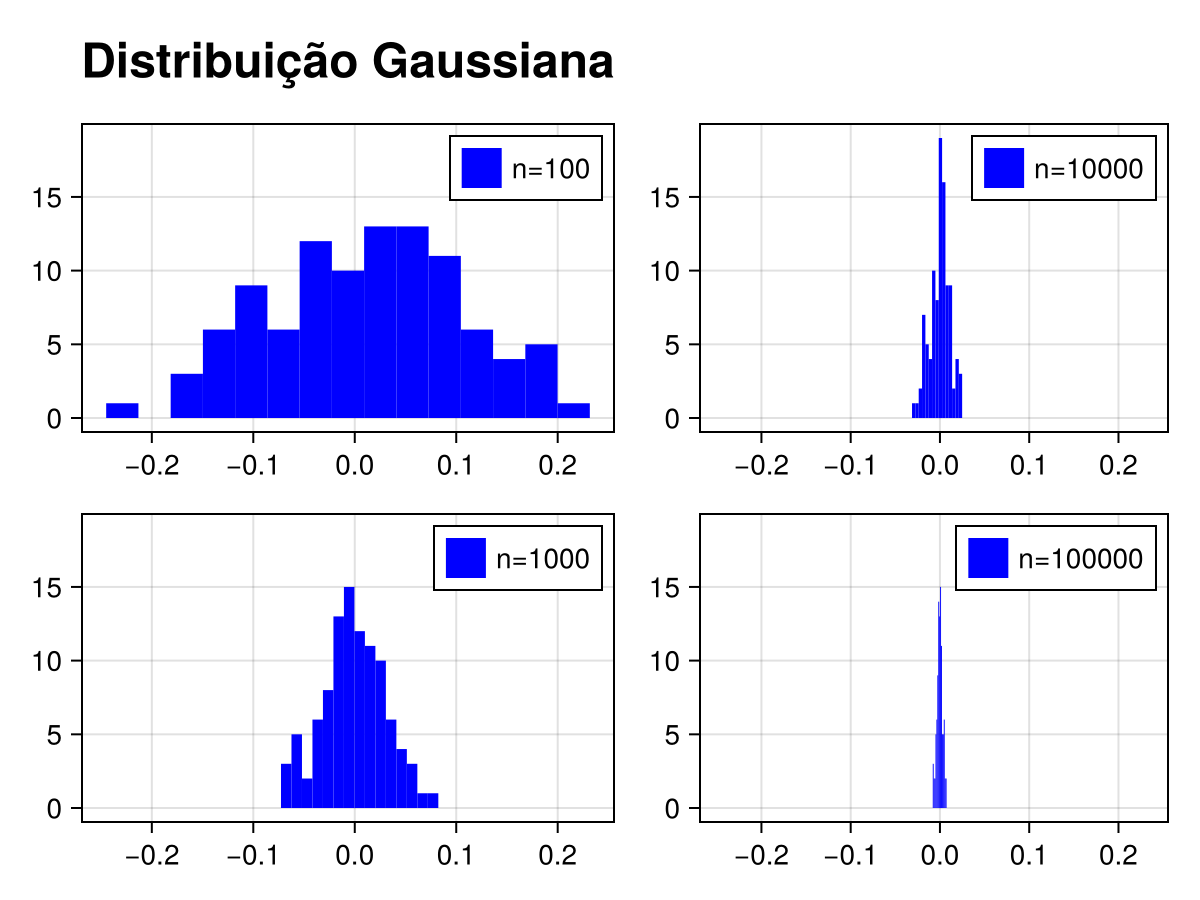

In [6]:
ex10_c.fig_gauss

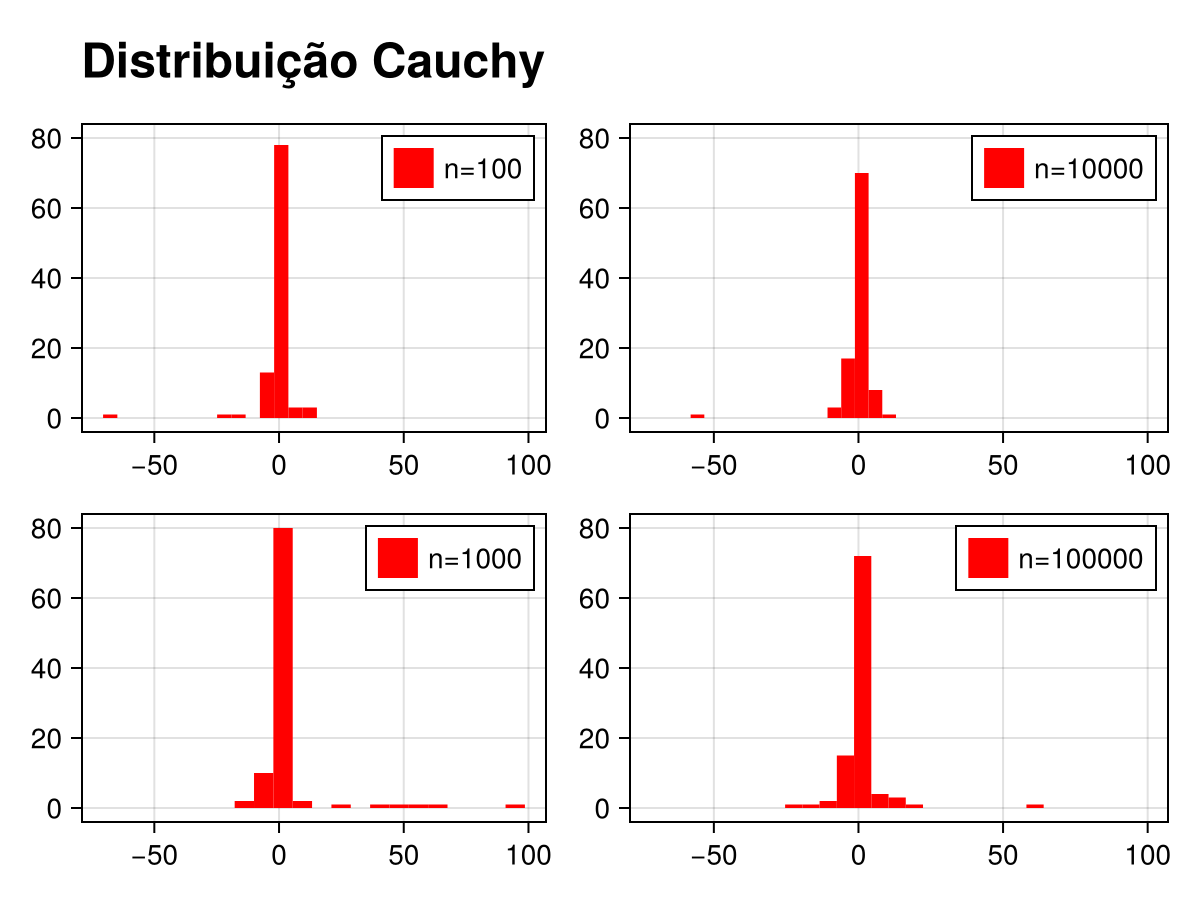

In [7]:
ex10_c.fig_cauchy

## d) 
O fato de a distribuição Gaussiana se estreitar é esperado pela Lei Dos Grandes Números, é fácil demonstrar que a média empiríca também segue uma distribuição gaussiana que o desvio padrão cai com $\frac{1}{\sqrt{N}}$ usando o fato que a soma de duas gaussianas é uma gaussiana ($\mathcal{N}(\mu_a,\sigma_a^2)+\mathcal{N}(\mu_b,\sigma_b^2)=\mathcal{N}(\mu_a+\mu_b,\sigma_a^2+\sigma_b^2)$)

$$X \sim \mathcal{N}(\mu,\sigma^2)$$

$$\frac{1}{N} \sum_i X_i=\frac{1}{N} X(N\mu,N*\sigma^2)=X(\mu,\sigma^2/N)$$

Como o próprio anunciado afirma, a média de uma distribuição de Cauchy é a própria distribuição de Cauchy, conforme $N \to \infty$ ela não se estreita, o que implica que a média empirica não converge.

## e)
Usando a mediana, o que se observa é que como ambas as distribuições são simétricas, é esperado
o mesmo número de elementos positivos e negativos, a mediana se aproxima de zero conforme $N \to \infty$,
o que faz com que a distribuição de Cauchy nesse caso tenha mediana amostral convergindo para zero

In [8]:
ex10_d=ex10_c_figures(median)

(fig_gauss = Scene(9 children, 0 plots), fig_cauchy = Scene(9 children, 0 plots))

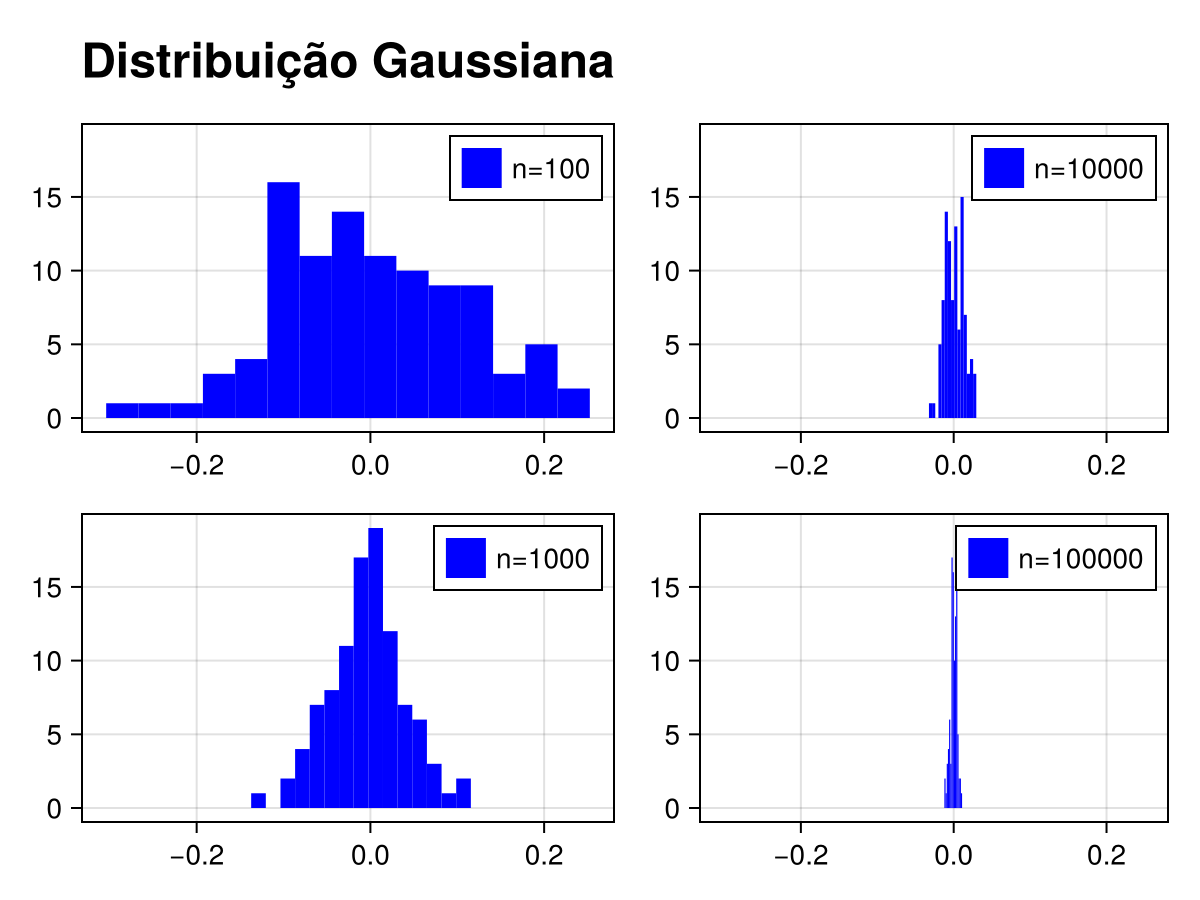

In [9]:
ex10_d.fig_gauss

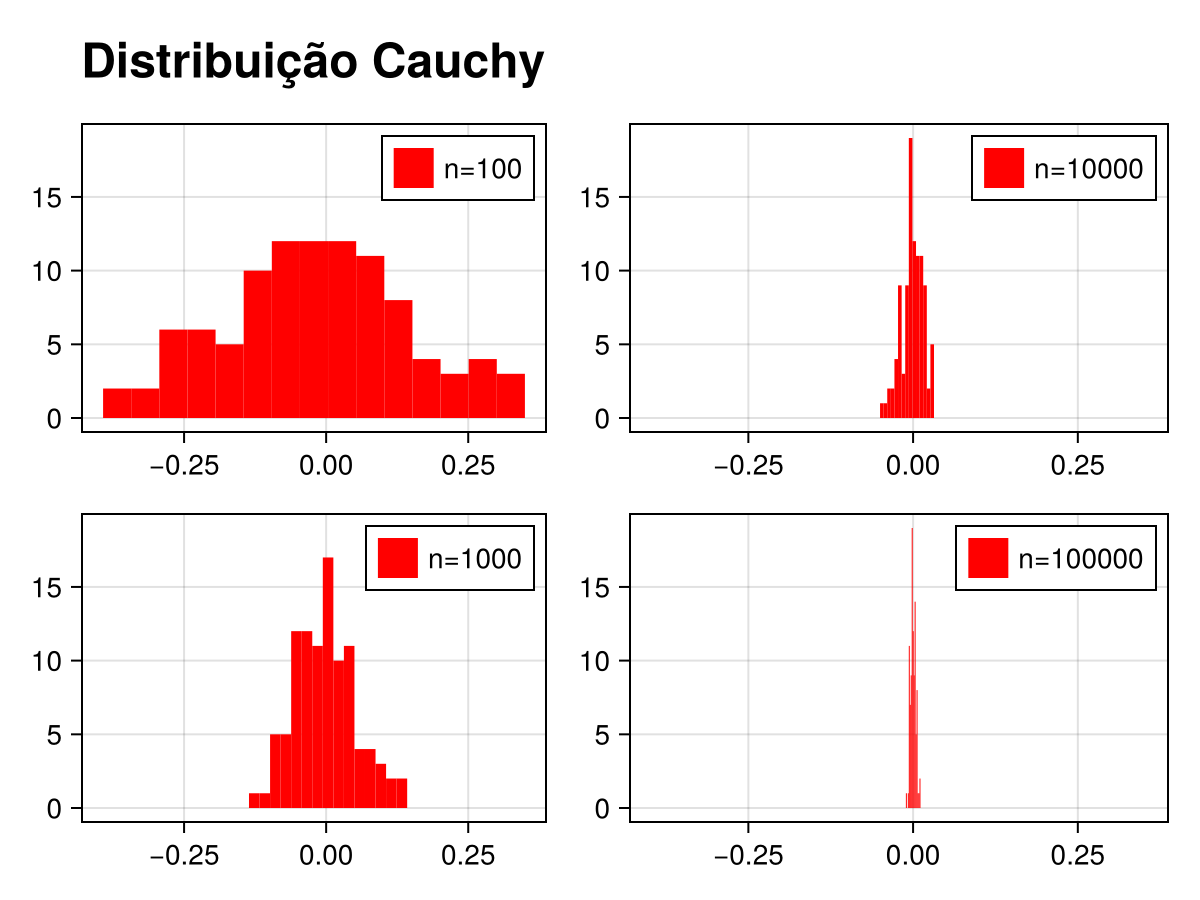

In [10]:
ex10_d.fig_cauchy

# Questão 11

## a)

Executando nove vezes com $n=1000$ se observa uma variação grande, algumas realizações de fato com média próxima de zero, outras claramente deslocadas para o lado positivo/negativo

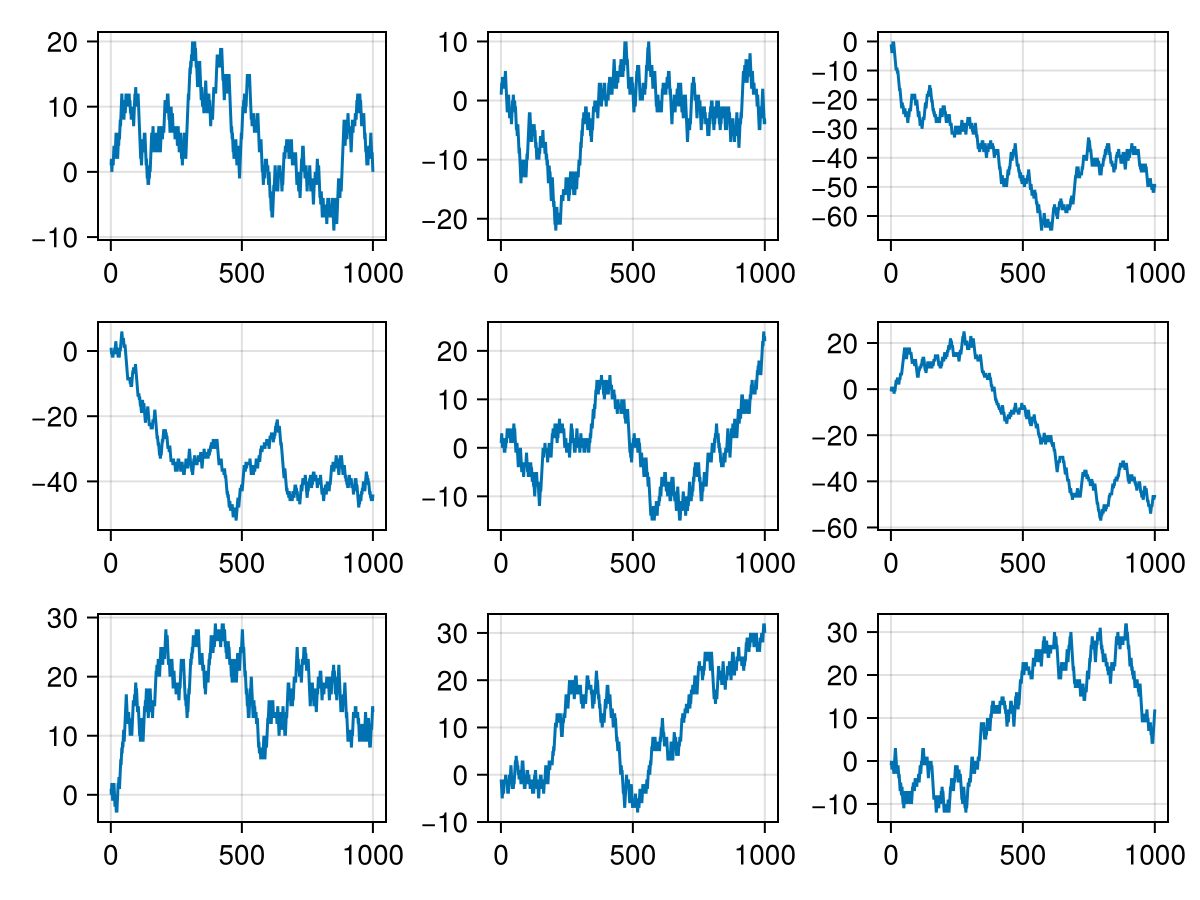

In [11]:
Y = DiscreteNonParametric([-1, 1], [0.5, 0.5])
fig=Figure()
n=1000
for i=1:3, j=1:3
    lines(fig[i,j],1:n,cumsum(rand(rng,Y,n)))
end
fig

## b) 

Como

$$
P(Y_i=1)=P(Y_i=-1)=\frac12,
$$

temos

$$
E[Y_i] = \frac12(1)+\frac12(-1) =
0.
$$

Além disso,

$$
\operatorname{Var}(Y_i) = E[Y_i^2]-E[Y_i]^2 =
1.
$$

Como

$$
X_n=\sum_{i=1}^n Y_i,
$$

pela linearidade da esperança,

$$
E[X_n] = \sum_{i=1}^n E[Y_i] = 0.
$$

Como as variáveis $Y_i$ são independentes, suas variâncias são aditivas:

$$
\operatorname{Var}(X_n) =
\sum_{i=1}^n \operatorname{Var}(Y_i) = n.
$$

Portanto, embora a esperança de $X_n$ permaneça igual a zero,
sua variância cresce linearmente com $n$. Consequentemente,$\sigma_{X_n}=\sqrt{n}$, isso explica as grandes flutuações

## c)

### Demostrando relação $X_n=2*K_n-n$
Chamando o conjunto de dias em alta de $A=\{i \in [1,...,n] | Y_i=1\}$, os dias de baixa são claramente $A^c$.
Como há $K_n$ de alta e $n-K_n$ de baixa, a soma total é os dias de alta
menos os dias de baixa $$X_n=K_n -(n-K_n)=2*K_n -n$$

### Distribuição de $K_n$
Isolando o $K_n$ da equação anterior
$$K_n=(X_n+n)/2$$
$$K_n=\sum_i ((Y_i +1)/2)$$

Vamos chamar $Z_i=(Y_i+1)/2$, temos que $P(Z_i=0)=P(Z_i=1)=1/2$, o que significa que Z $\sim$ Bernoulli(P=1/2).


$$K_n=\sum_i Z_i=\sum_i Bernoulli(p=1/2)=Binomial(N,p=1/2)$$

Portanto, $K_n$ $\sim$ Binomial(N,p=1/2).

### Expressão $P(X_n=x)$
Basta fazer $x=2*K_n-n$, $K_n=(x+n)/2$, o valor $k$ da distribuição de Binomial deve ser $(x+n)/2$. 

$$P(X=x)=\binom{n}{(x+n)/2}*(1/2)^{n}$$

Algo importante é que (x+n)/2 precisa ser um inteiro, por tanto x+n precisa ser par, $X_n$ não é exatamente uma binomial


## d)

###
Como $X_n=2*K_n-n$, $var(X_n)=var(2*K_n-n)=var(2*K_n)=4*var(K_n)$.

Portanto, $\sigma(X_n)=2*\sigma(K_n)$, $K_n$ é uma binomial, então $\sigma(K_n)=\sqrt{n*p*(1-p)}$.


Conforme o número de amostras cresce, o desvio padrão empirício se aproxima do teorico de $\sqrt{n}$

Os gráficos mostrados abaixo simplesmente colocam a distribuição P(X=x) encontrada analíticamente
em cima da encontrada computacionalmente

amostras 10 std_empirico=3.16 std_teorico=3.16
amostras 100 std_empirico=10.05 std_teorico=10.00
amostras 1000 std_empirico=31.57 std_teorico=31.62
amostras 10000 std_empirico=99.84 std_teorico=100.00


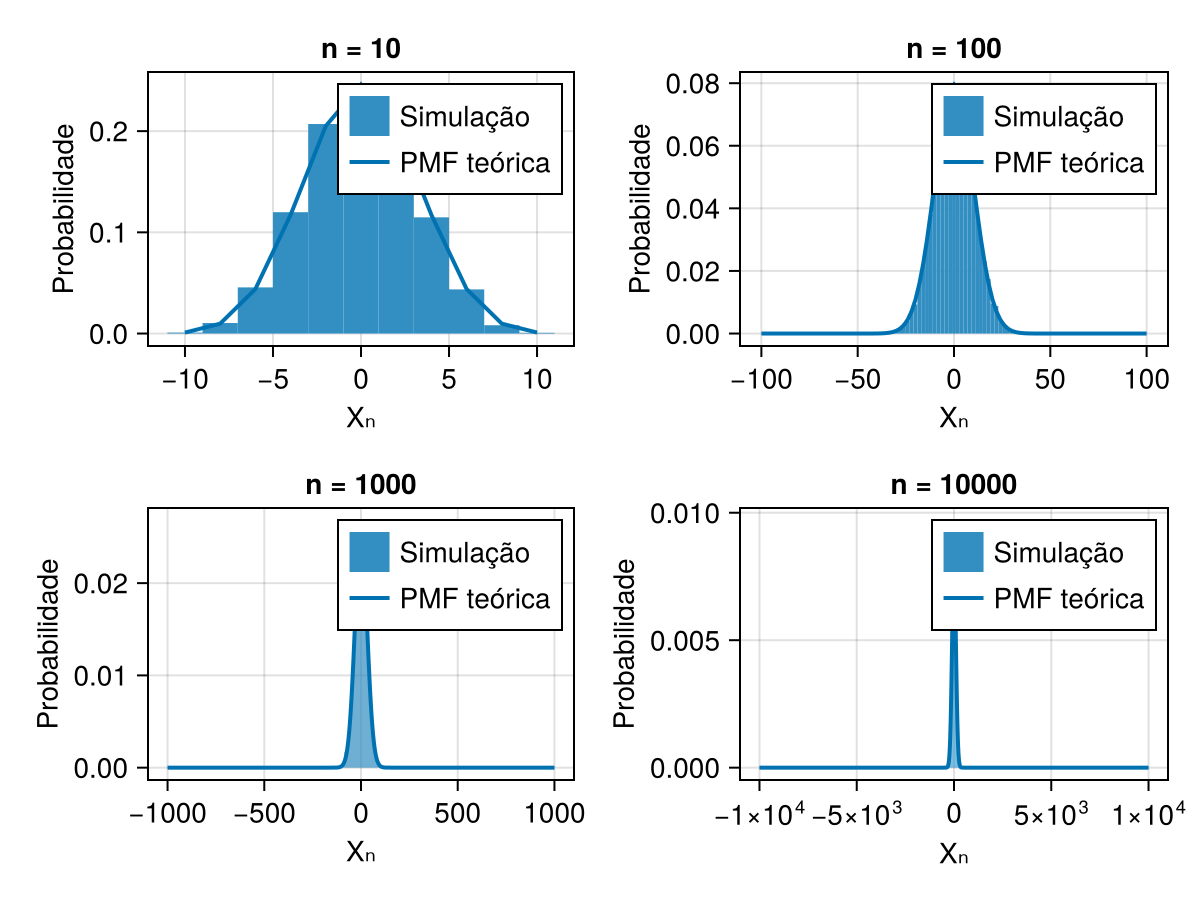

In [12]:
using Printf

X(n) = sum(rand(rng, Y, n))

ns = [10, 100, 1000, 10_000]
repetitions = 10_000

x_values = [
    [X(n) for _ in 1:repetitions]
    for n in ns
]

for (n, x) in zip(ns, x_values)
    @printf "amostras %d std_empirico=%.2f std_teorico=%.2f\n" n std(x) sqrt(n)
end

fig = Figure(scale=(3840,2160))

positions = [
    (1, 1),
    (1, 2),
    (2, 1),
    (2, 2),
]

for ((row, col), n, samples) in zip(positions, ns, x_values)
    ax = Axis(
        fig[row, col];
        title = "n = $n",
        xlabel = "Xₙ",
        ylabel = "Probabilidade",
    )
    bins = (-n - 1):2:(n + 1)

    hist!(
        ax,
        samples;
        bins,
        normalization = :probability,
        label = "Simulação",
    )
    x = -n:2:n
    k = (x .+ n) ./ 2
    p = pdf.(Binomial(n, 0.5), k)
    lines!(
        ax,
        x,
        p;
        linewidth = 2,
        label = "PMF teórica",
    )
    axislegend(ax)
end

fig

# Questão 12

## a)

Nos iremos amostrar a distribuição definida no $\mathbb{N}^2$ com um algoritmo de inversão cumulativa,
como esse algoritmo é para distribuições univariadas, iremos percorrer o $\mathbb{N}^2$ pelas suas diagonais,
dessa forma percorrendo todos os pares $(x,y) \in \mathbb{N}^2$

In [22]:
struct BivariatePoisson
    μx::Float64
    μy::Float64
    θ::Float64
end

function pmf(
    distr::BivariatePoisson,
    x::Integer,
    y::Integer,
)::Float64
    μx, μy, θ = distr.μx, distr.μy, distr.θ
    return exp(-(μx + μy - θ)) *
           ((μx - θ)^x / factorial(x)) *
           ((μy - θ)^y / factorial(y)) *
           sum(
               i -> binomial(x, i) *
                    binomial(y, i) *
                    factorial(i) *
                    (θ / ((μx - θ) * (μy - θ)))^i,
               0:min(x, y),
           )
end

function pontos_n2()
    Iterators.flatten(
        ((i, n - i) for i in 0:n)
        for n in Iterators.countfrom(0)
    )
end

function findfirstvalue(predicado,iterador)
    for x in iterador
        if predicado(x)
            return x
        end
    end
    return Nothing
end 

function amostrar_bivariate_poisson(
    rng::AbstractRNG,
    distr::BivariatePoisson,
)::Tuple{Int,Int}
    uniform = rand(rng)
    
    prob_acumulada = Iterators.accumulate(
        (state, point) -> (
            point = point,
            cumulative = state.cumulative + pmf(distr, point...),
        ),
        pontos_n2();
        init = (point = (0, 0), cumulative = 0.0),
    )
    return findfirstvalue(
        state->state.cumulative>uniform,
        prob_acumulada
    ).point
end

function amostrar_bivariate_poisson(
    rng::AbstractRNG,
    distr::BivariatePoisson,
    n::Integer,
)::Vector{Tuple{Int,Int}}
    return [
        amostrar_bivariate_poisson(rng, distr)
        for _ in 1:n
    ]
end


amostrar_bivariate_poisson (generic function with 2 methods)

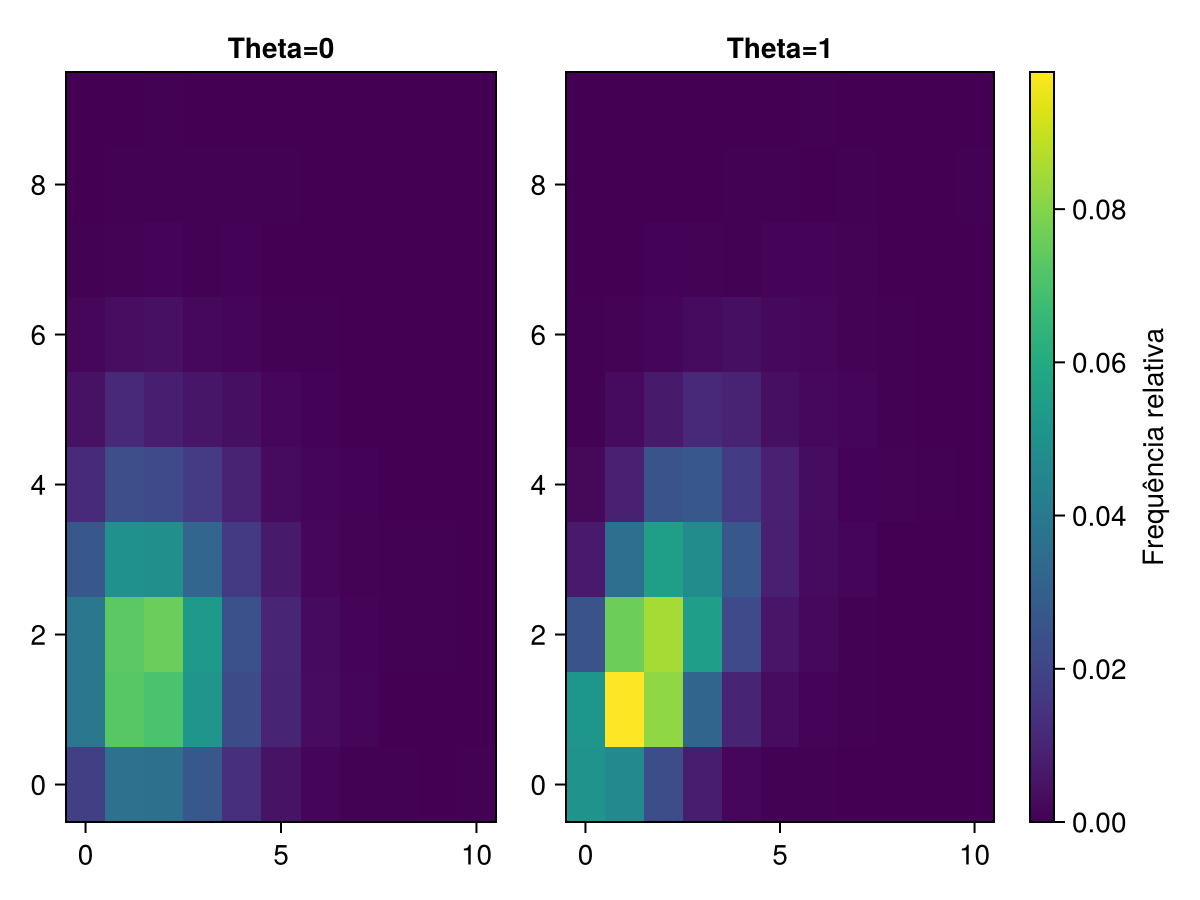

In [ ]:
function create_histogram(amostragens::Vector{Tuple{Int,Int}})
    x_max, y_max = reduce((a, b) -> max.(a, b), amostragens)
    frequencias=zeros(Int,x_max+1,y_max+1)
    for ((x,y),n) in countmap(amostragens)
        frequencias[x+1,y+1]=n
    end
    frequencias=frequencias ./ size(amostragens)
    frequencias,x_max,y_max
end
function 
μ_x=2.0
μ_y=2.0
N_samples=10_000
fig = Figure()
ax = Axis(fig[1, 1],title="Theta=0")
ax_cor=Axis(fig[1,2],title="Theta=1")
amostragens=amostrar_bivariate_poisson(rng,BivariatePoisson(μ_x,μ_y,0.0),N_samples)
amostragens_cor=amostrar_bivariate_poisson(rng,BivariatePoisson(μ_x,μ_y,1.0),N_samples)
freq,x_max,y_max=create_histogram(amostragens)
freq_cor,x_max_cor,y_max_cor=create_histogram(amostragens_cor)
max_freq = max(maximum(freq), maximum(freq_cor))
hm=heatmap!(ax,0:x_max,0:y_max,freq,colorrange=(0,max_freq))
heatmap!(ax_cor,0:x_max_cor,0:y_max_cor,freq_cor,colorrange=(0,max_freq))
Colorbar(
    fig[1, 3],
    hm,
    label = "Frequência relativa",
)

fig

## b)

Uma forma simples de amostrar essa distribuição é apartir da construção classíca da distribuição de Poisson bivariada, presente no artigo: GHOSH, I.; MARQUES, F.; CHAKRABORTY, S. A new bivariate Poisson distribution via conditional specification: properties and applications. Journal of Applied Statistics, v. 48, n. 16, p. 3025–3047, 10 dez. 2021. Só é necessário mudar a parametrização para bater com a do exercício.

Se $U \sim \text{Poisson}(\mu_x -\theta)$, $V \sim \text{Poisson}(\mu_y -\theta)$ e $Z \sim \text{Poisson}(\theta)$. Se construimos $X=U+Z$ e $Y=V+Z$, as variáveis $X,Y$ seguem a distribuição da equação 5, é intuitivo que aja uma correlação porque existe um fator aditivo em comum, então é esperado que exista um efeito de crescimento em conjunto.

In [26]:
function amostrar_bivariate_poisson_soma(
    rng::AbstractRNG,
    distr::BivariatePoisson,
    n::Int
)::Vector{Tuple{Int,Int}}
    U=Poisson(distr.μx)
    V=Poisson(distr.μy)
    Z=Poisson(distr.θ)
    [
        begin
            z = rand(rng, Z)
            (rand(rng, U) + z, rand(rng, V) + z)
        end
        for _ in 1:n
    ]
end

display(@benchmark amostrar_bivariate_poisson_soma(Xoshiro(123456789),BivariatePoisson(2.0,2.0,0.5),1000))
display(@benchmark amostrar_bivariate_poisson(Xoshiro(123456789),BivariatePoisson(2.0,2.0,0.5),1_000))

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  65.119 μs … 178.826 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     67.103 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   68.970 μs ±   6.409 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▃▇█▆▆▅▄▃▃▂▂▂▁   ▁                                            ▂
  ██████████████████▇█▆▆▇▇▇▆▅▅▅▅▄▄▃▃▄▆▃▅▅▅▅▃▆▅▅▃▅▅▆▄▄▅▅▅▆▆▅▅▄▂ █
  65.1 μs       Histogram: log(frequency) by time       105 μs <

 Memory estimate: 16.10 KiB, allocs estimate: 11.

BenchmarkTools.Trial: 5803 samples with 1 evaluation per sample.
 Range (min … max):  816.871 μs …  1.405 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     842.747 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   861.120 μs ± 61.687 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▄▁▅█▅▄▄▃▂▁▁▂▁▁ ▁    ▁                                        ▁
  ██████████████████████▇▇▇▅▆▆▅▅▆▅▄▃▄▄▅▅▄▅▄▃▃▃▄▃▄▃▅▄▃▁▃▄▄▁▁▃▁▃ █
  817 μs        Histogram: log(frequency) by time      1.25 ms <

 Memory estimate: 16.10 KiB, allocs estimate: 11.

## c)

Como $U$, $V$ e $W$ são independentes,

$$\operatorname{cov}(X,Y)=\operatorname{cov}(U+W,V+W)=\operatorname{Var}(W)=\theta.$$

Além disso, $\operatorname{Var}(X)=\mu_X$ e $\operatorname{Var}(Y)=\mu_Y$. Portanto,

$$\rho_{X,Y}=\frac{\theta}{\sqrt{\mu_X\mu_Y}}.$$

Como $\theta\geq0$, essa construção nunca pode produzir correlação negativa.

## d)

Para a Eq. (6), implementamos uma segunda distribuição. Sua constante de normalização é calculada no construtor e reutilizada por `pdf`. O sampler é exato: propõe $Y\sim\operatorname{Poisson}(\lambda_Y)$, aceita-o com probabilidade $\exp[\lambda_X(\lambda^Y-1)]$ e então sorteia $X\mid Y=y\sim\operatorname{Poisson}(\lambda_X\lambda^y)$. Portanto, não há truncamento da distribuição nem período de aquecimento de uma cadeia de Markov.

In [16]:
function conditional_log_normalizer(λx::T, λy::T, λ::T) where {T<:AbstractFloat}
    λ == one(T) && return λx + λy
    proposal = Poisson(λy)
    logz = -T(Inf)
    y = 0
    cutoff = max(10, ceil(Int, 2 * λy))
    while true
        logterm = logpdf(proposal, y) + λy + λx * λ^y
        logz = _logaddexp(logz, logterm)
        y >= cutoff && logterm < logz + log(eps(T) / 2) && return logz
        y += 1
    end
end

struct ConditionalBivariatePoisson{T<:AbstractFloat} <: DiscreteMultivariateDistribution
    λx::T
    λy::T
    λ::T
    logz::T
end

function ConditionalBivariatePoisson(λx::Real, λy::Real, λ::Real)
    λx, λy, λ = promote(float(λx), float(λy), float(λ))
    λx > 0 || throw(ArgumentError("λx deve ser positivo"))
    λy > 0 || throw(ArgumentError("λy deve ser positivo"))
    0 < λ <= 1 || throw(ArgumentError("λ deve satisfazer 0 < λ ≤ 1"))
    logz = conditional_log_normalizer(λx, λy, λ)
    ConditionalBivariatePoisson{typeof(λx)}(λx, λy, λ, logz)
end

Base.length(::ConditionalBivariatePoisson) = 2
Distributions.params(d::ConditionalBivariatePoisson) = (d.λx, d.λy, d.λ)
Distributions.partype(::ConditionalBivariatePoisson{T}) where {T} = T
Distributions.insupport(::ConditionalBivariatePoisson, z::AbstractVector) =
    length(z) == 2 && all(v -> v >= 0 && isinteger(v), z)

function Distributions._logpdf(d::ConditionalBivariatePoisson,
                               z::AbstractVector{<:Real})
    insupport(d, z) || return -Inf
    x, y = Int.(z)
    logpdf(Poisson(d.λx), x) + d.λx +
    logpdf(Poisson(d.λy), y) + d.λy +
    x * y * log(d.λ) - d.logz
end

struct ConditionalBivariatePoissonSampler{T,S} <: Sampleable{Multivariate,Discrete}
    λx::T
    λ::T
    y_proposal::S
end

Base.length(::ConditionalBivariatePoissonSampler) = 2
Distributions.sampler(d::ConditionalBivariatePoisson) =
    ConditionalBivariatePoissonSampler(
        d.λx, d.λ, Distributions.sampler(Poisson(d.λy))
    )

function Distributions._rand!(rng::AbstractRNG, s::ConditionalBivariatePoissonSampler,
                              z::AbstractVector{<:Real})
    y = rand(rng, s.y_proposal)
    while log(rand(rng)) > s.λx * (s.λ^y - 1)
        y = rand(rng, s.y_proposal)
    end
    z[1] = rand(rng, Poisson(s.λx * s.λ^y))
    z[2] = y
    z
end

Distributions._rand!(rng::AbstractRNG, d::ConditionalBivariatePoisson,
                     z::AbstractVector{<:Real}) =
    Distributions._rand!(rng, Distributions.sampler(d), z)

In [17]:
d_negative = ConditionalBivariatePoisson(2, 2, 0.2)
samples_negative = rand(rng_12, d_negative, n_12)
h_negative = histogram2d(samples_negative, 7, 7)
ρ_negative = cor(samples_negative; dims=2)[1, 2]

fig_negative = Figure(size=(470, 380))
ax_negative = Axis(
    fig_negative[1, 1];
    title="λ = 0,2; ρ empírico = $(round(ρ_negative; digits=3))",
    xlabel="x",
    ylabel="y",
)
hm_negative = heatmap!(ax_negative, 0:7, 0:7, h_negative)
Colorbar(fig_negative[1, 2], hm_negative; label="Frequência relativa")
fig_negative

UndefVarError: UndefVarError: `_logaddexp` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Checagens numéricas

A célula abaixo verifica normalização, momentos da Eq. (5) e o sinal negativo obtido na Eq. (6).

In [18]:
@assert isapprox(
    sum(pdf(d_correlated, [x, y]) for x in 0:25, y in 0:25),
    1; atol=1e-10,
)
@assert isapprox(vec(mean(samples_correlated; dims=2)), mean(d_correlated); atol=0.05)
@assert isapprox(cov(samples_correlated; dims=2), cov(d_correlated); atol=0.08)
@assert isapprox(
    sum(pdf(d_negative, [x, y]) for x in 0:25, y in 0:25),
    1; atol=1e-10,
)
@assert ρ_negative < 0

"Checagens da questão 12 concluídas."

UndefVarError: UndefVarError: `d_correlated` not defined in `Main`
Suggestion: check for spelling errors or missing imports.